# Leap Seconds

In [19]:
import numpy as np
import scipy as sp
import scipy.constants as sc
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

plt.rcParams.update({
    'figure.dpi': 300,
    "font.size": 7,       # base font size
    "axes.labelsize": 8,  # x/y axis labels
    "xtick.labelsize": 7,  # x tick labels
    "ytick.labelsize": 7,  # y tick labels
    "axes.titlesize": 10,  # title
    "legend.fontsize": 7,
})

def seconds_to_hhmm(x, pos):
    total_minutes = round(x / 60)
    hours = total_minutes // 60
    minutes = total_minutes % 60
    return f"{hours:02d}h{minutes:02d}m"

def seconds_to_h(x, pos):
    hours = int(x // 3600)
    return f"{hours:d}h"

def seconds_to_mmss(x, pos):
    minutes = int(x // 60)
    seconds = int(x - minutes * 60)
    return f"{minutes:02d}m{seconds:02d}s"

Length of day increase rate in seconds/year

In [20]:
D = 1.7/1000 / 100  # 1.7 ms per century

In [21]:
D

1.7e-05

## Leap seconds in the future

In [22]:
def length_of_day_delta(year): return year*D

In [23]:
length_of_day_delta(100) * 365

0.6204999999999999

In [24]:
def t_of_day_shift(year):
    return length_of_day_delta(year) / 2 * year * 365

In [25]:
t_of_day_shift(8000)

198560.0

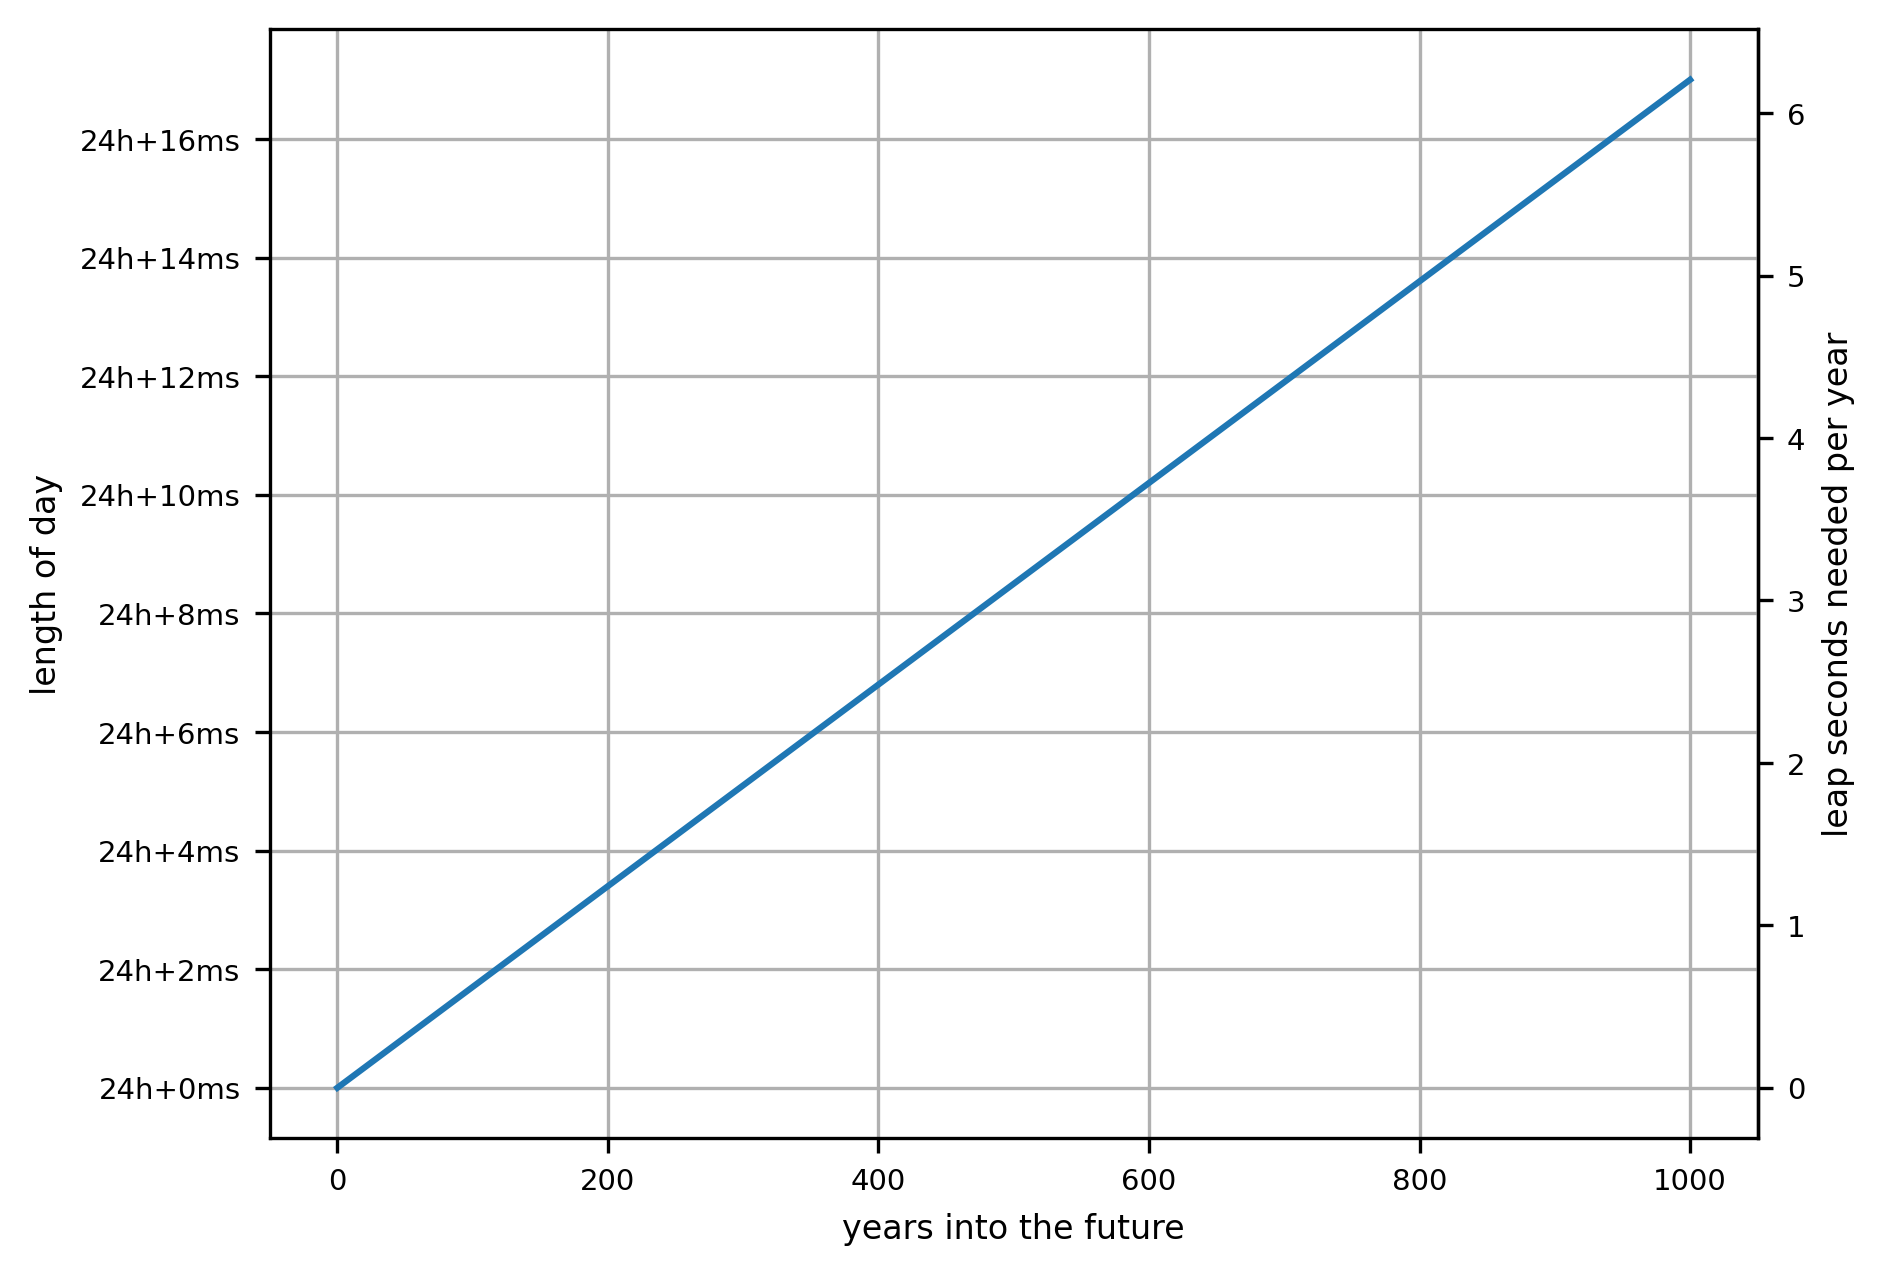

In [26]:
years = np.linspace(0,1000,100)
leapsec_per_year = length_of_day_delta(years) * 365
fig, ax = plt.subplots()
ax.plot(years, length_of_day_delta(years))
ax.set_xlabel("years into the future")

ax.set_ylabel("length of day")

def day_delta_to24hplusx(sec, pos):
    return f"24h+{int(sec*1000):d}ms"

ax.yaxis.set_major_formatter(FuncFormatter(day_delta_to24hplusx))
ax.yaxis.set_major_locator(MultipleLocator(0.002))
ax.grid(True)

secax = ax.secondary_yaxis(
    location='right',
    functions=(lambda daylength_delta: daylength_delta/sc.day * sc.year,
               lambda leapsec_per_year: leapsec_per_year/sc.year * sc.day)
)
secax.set_ylabel('leap seconds needed per year')

secax.grid(True)

Text(0, 0.5, 'cumulative time of day deviation')

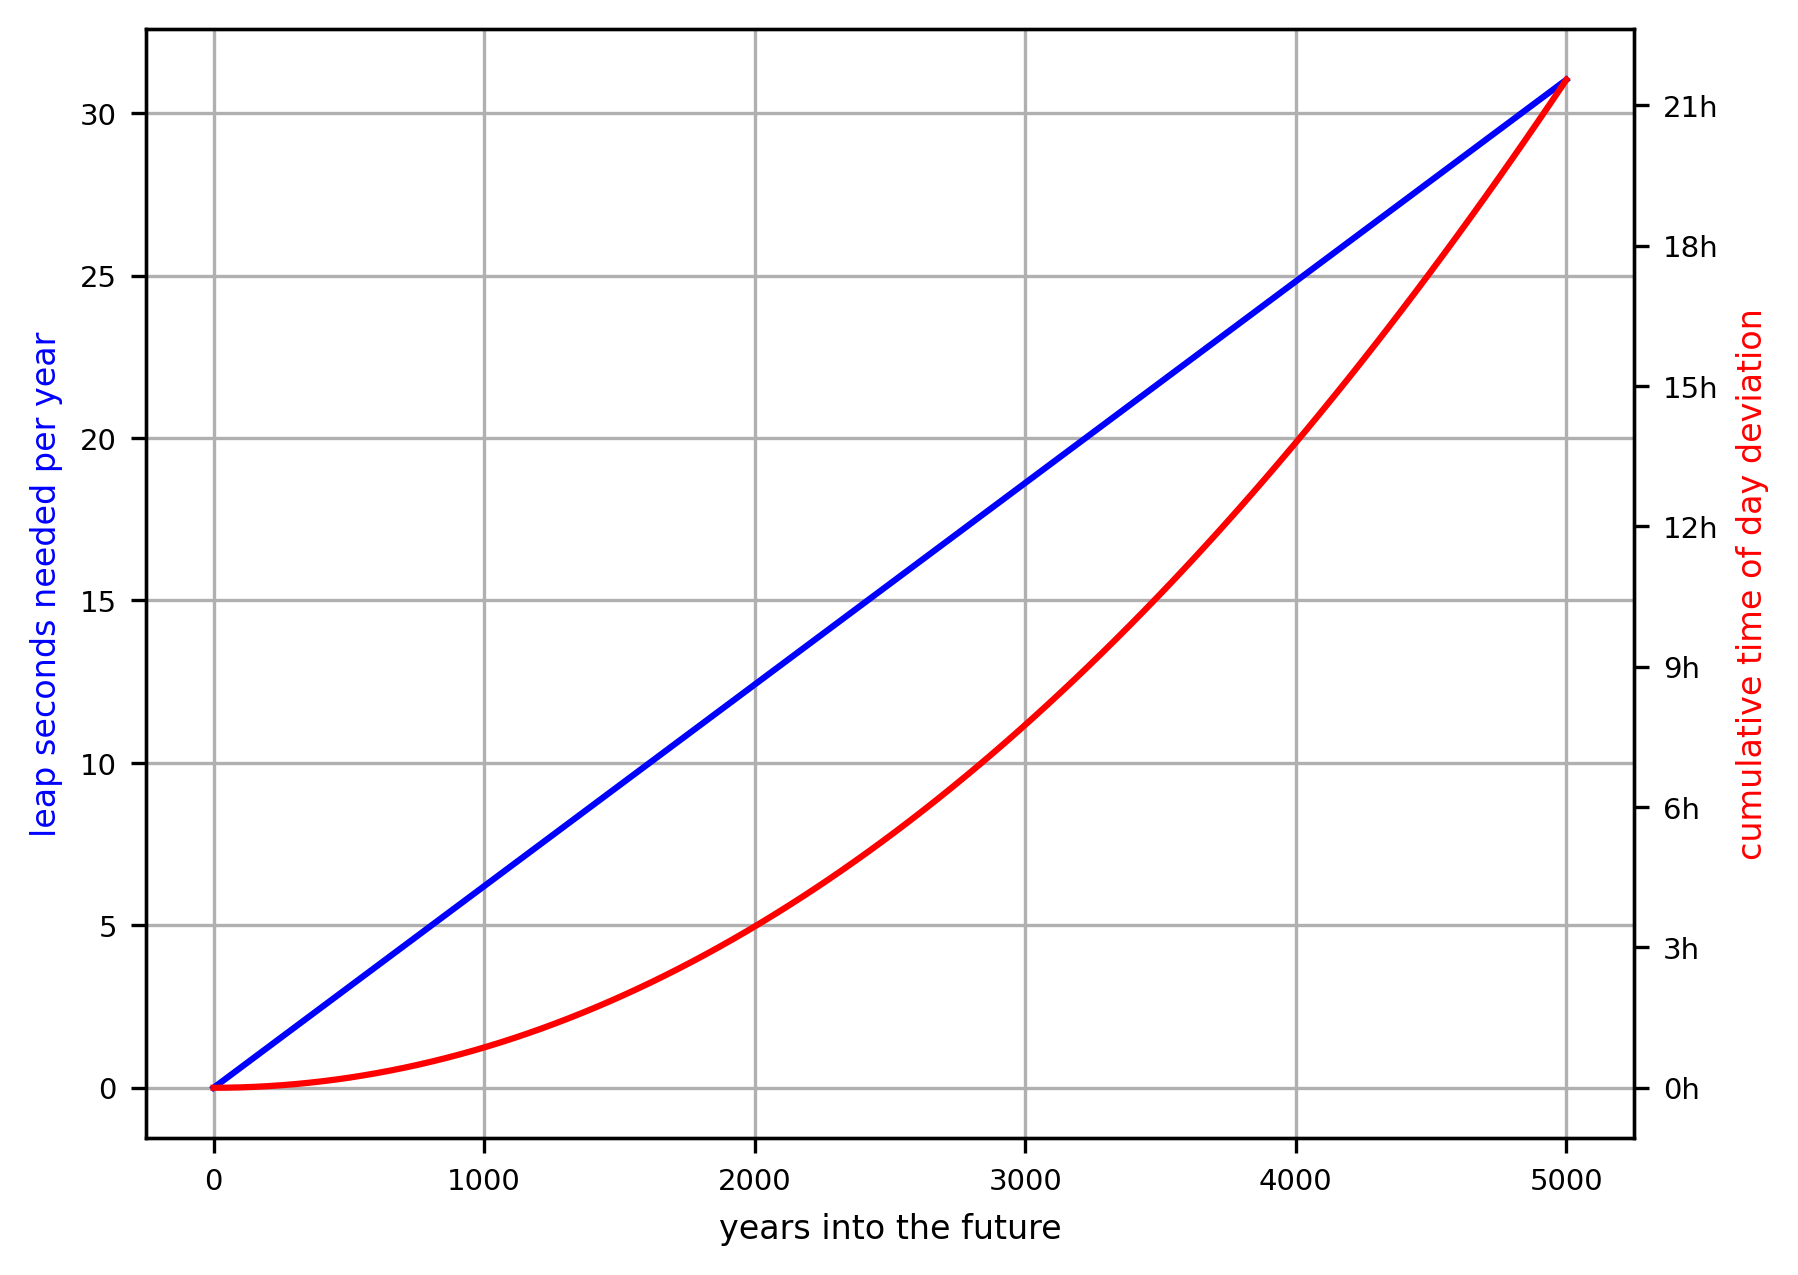

In [27]:
years = np.linspace(0,5000,100)
fig, ax = plt.subplots()
ax.plot(years, length_of_day_delta(years) * 365, 'b-')
ax.set_xlabel("years into the future")
ax.set_ylabel("leap seconds needed per year", color='b')
#ax.set_ylim(0, 7)
ax.grid(True)

ax2 = ax.twinx()
ax2.plot(years, t_of_day_shift(years), 'r-')
ax2.yaxis.set_major_formatter(FuncFormatter(seconds_to_h))
ax2.yaxis.set_major_locator(MultipleLocator(3*3600))
#ax2.set_ylim(0, 3600)
ax2.set_ylabel("cumulative time of day deviation", color='r')

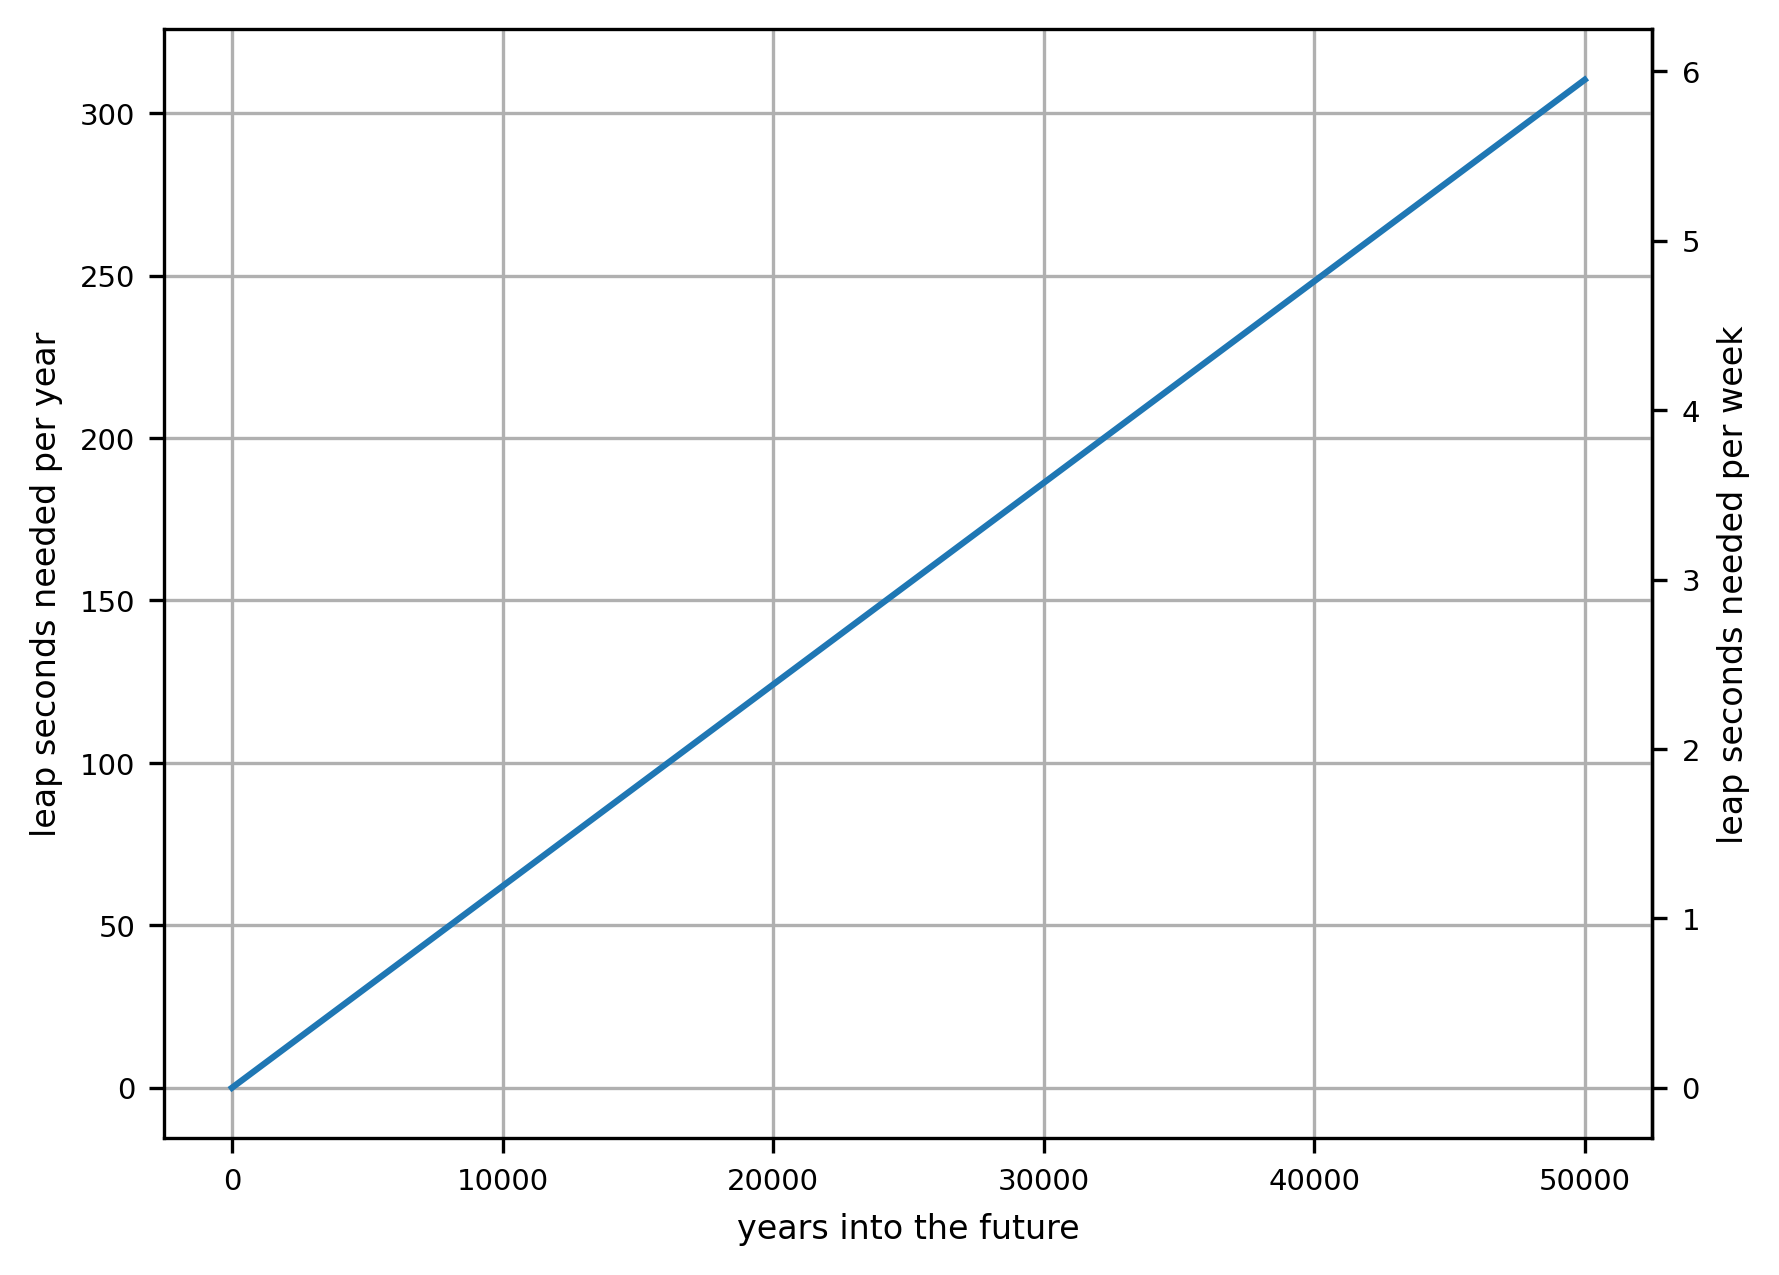

In [28]:
years = np.linspace(0,50000,100)
leapsec_per_year = length_of_day_delta(years) * 365
fig, ax = plt.subplots()
ax.plot(years, leapsec_per_year)
ax.set_xlabel("years into the future")
ax.set_ylabel("leap seconds needed per year")
ax.grid(True)
secax = ax.secondary_yaxis(location='right', functions=(lambda year: year*7/365, lambda week: week*365/7))
secax.set_ylabel('leap seconds needed per week')
secax.grid(True)

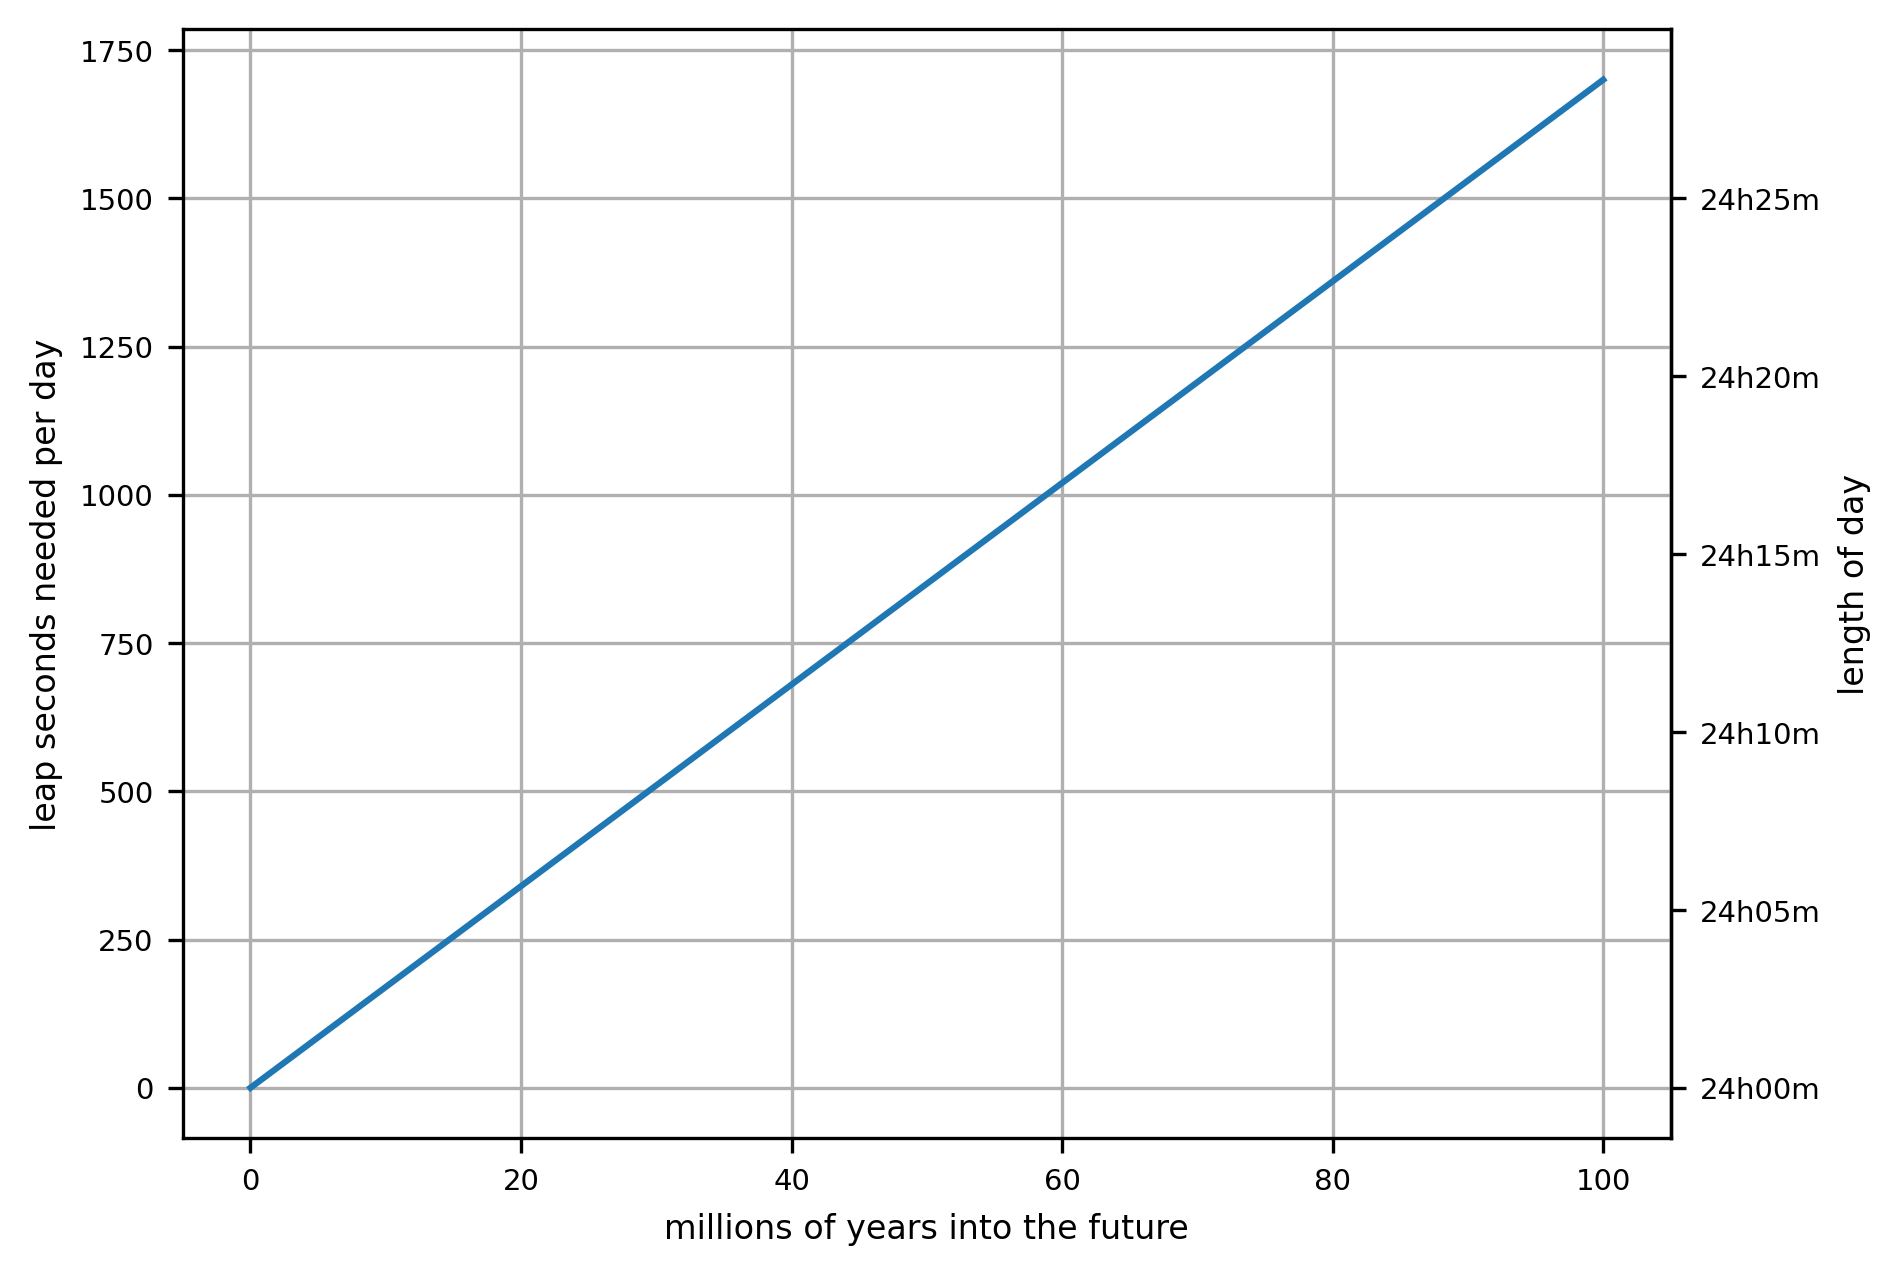

In [29]:
years = np.linspace(0,100e6,100)
leapsec_per_day = length_of_day_delta(years)
fig, ax = plt.subplots()
ax.plot(years/1e6, leapsec_per_day)
ax.set_xlabel("millions of years into the future")
ax.set_ylabel("leap seconds needed per day")
ax.grid(True)
secax = ax.secondary_yaxis(location='right', functions=(lambda lpd: lpd + 24*3600, lambda day: day - 24*3600))
secax.set_ylabel('length of day')
secax.yaxis.set_major_formatter(FuncFormatter(seconds_to_hhmm))
secax.yaxis.set_major_locator(MultipleLocator(300))
secax.grid(True)